In [20]:
# imports 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


## Pre-ML Processing

**Goal**: Prepare dataset for ML modelling

**Issues**:
* Dataset imbalance
* Aggregation of data_type and data_subject_type

In [18]:
df_health_original = pd.read_csv("data-security-incident-trends-health-sector.csv")

# create a new df for ML models that includes unique incidents with aggregated data_subject_type and data_type features
df_health_ml = (
    df_health_original
    .groupby("bi_reference", observed=True)
    .agg({
        "year": "first",
        "quarter": "first",
        "data_subject_type": lambda x: ', '.join(sorted(x.unique())),
        "data_type": lambda x: ', '.join(sorted(x.unique())),
        "decision_taken": "first",
        "incident_category": "first",
        "incident_type": "first",
        "no_data_subjects_affected": "first",
        "time_taken_to_report": "first",
    })
    .reset_index()
)

# drop bi_reference as not needed for modelling
df_health_ml = df_health_ml.drop(columns=["bi_reference"])

# drop the 'Not Yet Assigned' rows as they are administrative
df_health_ml = df_health_ml[df_health_ml["decision_taken"] != "Not Yet Assigned"].reset_index(drop=True)

# verify new df
df_health_ml.info()
#df_health_ml.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8327 entries, 0 to 8326
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       8327 non-null   int64 
 1   quarter                    8327 non-null   object
 2   data_subject_type          8327 non-null   object
 3   data_type                  8327 non-null   object
 4   decision_taken             8327 non-null   object
 5   incident_category          8327 non-null   object
 6   incident_type              8327 non-null   object
 7   no_data_subjects_affected  8327 non-null   object
 8   time_taken_to_report       8327 non-null   object
dtypes: int64(1), object(8)
memory usage: 585.6+ KB


In [14]:
# define the test period: train 2021 Q2 - 2024 Q1, test 2024 Q2 - 2025 Q1 & Q2
def test_period(row):
    return (((row["year"] == 2024) and (row["quarter"] in ["Qtr 4"])) or ((row["year"] == 2025) and (row["quarter"] in ["Qtr 1", "Qtr 2"])))

# temp column to check train vs test split
df_health_ml["is_test"] = df_health_ml.apply(test_period, axis=1)
print(df_health_ml["is_test"].value_counts())

# split into train and test sets
df_train = df_health_ml[df_health_ml["is_test"] == False].reset_index(drop=True)
df_test = df_health_ml[df_health_ml["is_test"] == True].reset_index(drop=True)

# drop temp column
df_health_ml = df_health_ml.drop(columns=["is_test"])

# summary of years and quarters in train vs test sets
print("\nTraining set:\n", df_train[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]))
print("\nTest set:\n", df_test[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]))

is_test
False    6766
True     1561
Name: count, dtype: int64

Training set:
       year quarter
0     2021   Qtr 2
603   2021   Qtr 3
1035  2021   Qtr 4
1496  2022   Qtr 1
1917  2022   Qtr 2
2348  2022   Qtr 3
2829  2022   Qtr 4
3269  2023   Qtr 1
3723  2023   Qtr 2
4181  2023   Qtr 3
4682  2023   Qtr 4
5121  2024   Qtr 1
5631  2024   Qtr 2
6165  2024   Qtr 3

Test set:
       year quarter
0     2024   Qtr 4
546   2025   Qtr 1
1072  2025   Qtr 2


In [15]:
# check distribution of target variable (decision taken) in original, train and test sets
print(df_health_ml["decision_taken"].value_counts())
print(df_train["decision_taken"].value_counts())
print(df_test["decision_taken"].value_counts())

# summary of decision_taken in train vs test sets
print("\nTraining set decision_taken proportion:")
print(df_train["decision_taken"].value_counts(normalize=True))
print("\nTest set decision_taken proportion:")
print(df_test["decision_taken"].value_counts(normalize=True))

decision_taken
Informal Action Taken    6794
No Further Action         948
Investigation Pursued     585
Name: count, dtype: int64
decision_taken
Informal Action Taken    5332
No Further Action         876
Investigation Pursued     558
Name: count, dtype: int64
decision_taken
Informal Action Taken    1462
No Further Action          72
Investigation Pursued      27
Name: count, dtype: int64

Training set decision_taken proportion:
decision_taken
Informal Action Taken    0.788058
No Further Action        0.129471
Investigation Pursued    0.082471
Name: proportion, dtype: float64

Test set decision_taken proportion:
decision_taken
Informal Action Taken    0.936579
No Further Action        0.046124
Investigation Pursued    0.017297
Name: proportion, dtype: float64


In [16]:
# final check of new df structure
df_health_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8327 entries, 0 to 8326
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       8327 non-null   int64 
 1   quarter                    8327 non-null   object
 2   data_subject_type          8327 non-null   object
 3   data_type                  8327 non-null   object
 4   decision_taken             8327 non-null   object
 5   incident_category          8327 non-null   object
 6   incident_type              8327 non-null   object
 7   no_data_subjects_affected  8327 non-null   object
 8   time_taken_to_report       8327 non-null   object
dtypes: int64(1), object(8)
memory usage: 585.6+ KB


In [ ]:
# function for evaluation metrics 
def evaluate_model(y_true, y_pred, labels=None):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    # display confusion matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.plasma)
    plt.title("Confusion Matrix")
    plt.show()
    
    print(f"Accuracy Score: {accuracy_score(y_true, y_pred)}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0)}")
    print(f"Recall: {recall_score(y_true, y_pred, average='macro', zero_division=0)}")
    print(f"F1 Score: {f1_score(y_true, y_pred, average='macro', zero_division=0)}")

Train size: 6766 Test size: 1561
Train: {'Informal Action Taken': 5332, 'Investigation Pursued': 558, 'No Further Action': 876}
Test: {'Informal Action Taken': 1462, 'Investigation Pursued': 27, 'No Further Action': 72}
Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.74      0.83      1462
Investigation Pursued       0.03      0.30      0.05        27
    No Further Action       0.18      0.38      0.24        72

             accuracy                           0.71      1561
            macro avg       0.39      0.47      0.37      1561
         weighted avg       0.91      0.71      0.79      1561

Confusion Matrix:
[[1075  264  123]
 [  16    8    3]
 [  32   13   27]]


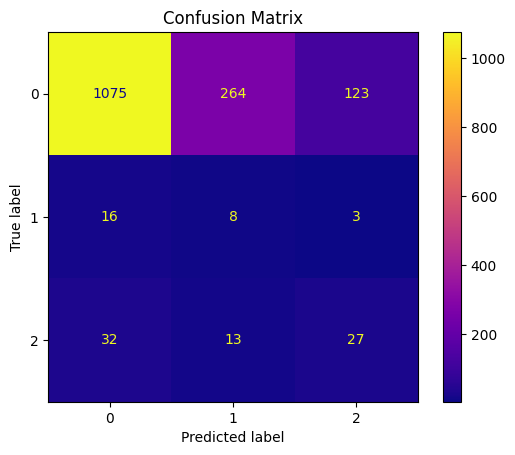

Accuracy Score: 0.7110826393337604
Precision: 0.38726603668915976
Recall: 0.4688634713144517
F1 Score: 0.3743345071004646


In [21]:
# Baseline random forest classifier
FEATURE_COLS = ["incident_type", "incident_category", "no_data_subjects_affected", "time_taken_to_report"]
TARGET_COL = "decision_taken"

# Training and test sets
X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]

X_test = df_test[FEATURE_COLS]
y_test = df_test[TARGET_COL]

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Train:", y_train.value_counts().sort_index().to_dict())
print("Test:", y_test.value_counts().sort_index().to_dict())

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_COLS)])

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"))
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
evaluate_model(y_test, y_pred)

34
    original_feature  importance
0      incident_type    0.454022
1                 no    0.221880
2  incident_category    0.163160
3               time    0.160937


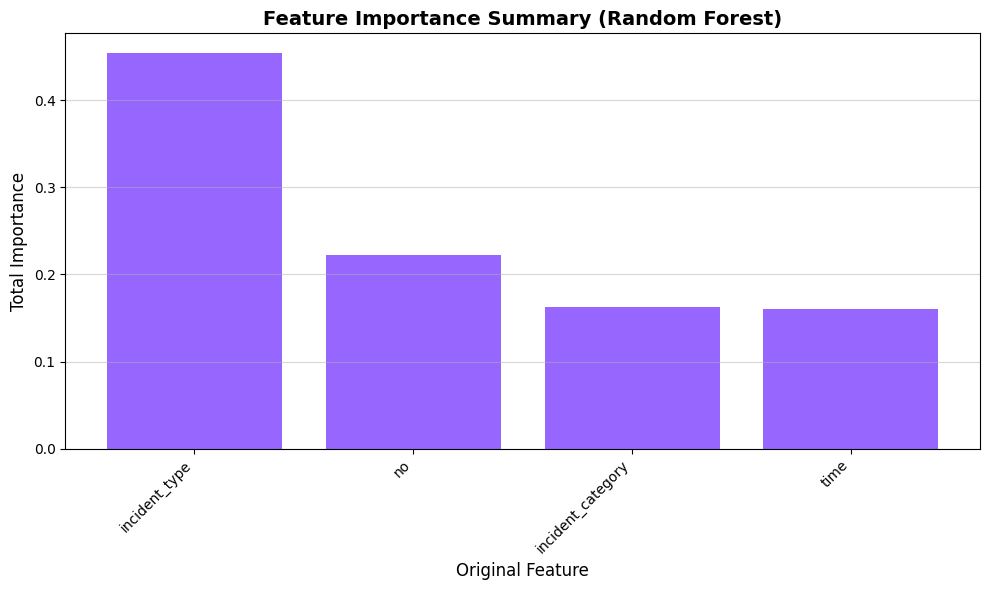

In [22]:
# extract feature importance to see what the model is learning from
rf_model = rf_pipeline.named_steps["model"]
encoded_model = rf_pipeline.named_steps["preprocess"].named_transformers_["cat"]
feature_names = encoded_model.get_feature_names_out(FEATURE_COLS)
feature_importances = rf_model.feature_importances_

# create a dataframe of feature importance and sort by importance
importances_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

# how many features are there after encoding
print(len(importances_df))

# display the top 20 most important features
importances_df.head(20)

# group the feature importance by original feature to see which features are most important overall
# separate incident type and category as they both start with incident
importances_df["original_feature"] = importances_df["feature"].apply(lambda x: x.split("_")[0] if not x.startswith("incident") else "_".join(x.split("_")[:2]))

feature_importance_summary = (
    importances_df
    .groupby("original_feature", observed=False)["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print(feature_importance_summary)

# bar chart of feature importance summary
plt.figure(figsize=(10, 6))
bars = plt.bar(
    feature_importance_summary["original_feature"],
    feature_importance_summary["importance"],
    color= "#9666ff"
)
plt.title("Feature Importance Summary (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Original Feature", fontsize=12)
plt.ylabel("Total Importance", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()